In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
working_directory = "/Users/kemalinecik/git_nosync/sctram"

In [3]:
import sys
sys.path.append(working_directory)

import logging
import os
import numpy as np
import pandas as pd
import networkx as nx
import scanpy as sc
import anndata as ad
from sctram.generate.real import sc_norman_sciplex_cpa

sc.settings.verbosity = 3

In [16]:
from sctram.infer._pca import PCAEmbedding
from sctram.infer._umap import UMAPEmbedding
from sctram.infer._diffmap import DiffmapEmbedding
from sctram.infer._obsm import ObsmEmbedding

from sctram.evaluate._embedding import EmbeddingTrajectoryEvaluation
from sctram.input import read_dict

In [5]:
%matplotlib inline
%config InlineBackend.figure_format='retina'
import matplotlib.pyplot as plt
import seaborn as sns

import pickle
_rcparams_path = os.path.join(working_directory, "reproducibility/figure_rcparams/rcparams.pickle")
with open(_rcparams_path, 'rb') as file:
    _rcparams = pickle.load(file)
plt.rcParams.update(_rcparams)

In [6]:
dataset_dir = "/Users/kemalinecik/git_nosync/sctram/__temp__/data"
adata_norman = sc_norman_sciplex_cpa(dataset_dir=dataset_dir)
adata_bms = adata_norman[["bms" in i.lower() or "vehicle" in i.lower() for i in adata_norman.obs["drug"]]]

# Input

In [7]:
ground_truth_trajectories = {
    "trajectory_1": [
        ('Vehicle_1.0', 'BMS_0.001'),
        ('BMS_0.001', 'BMS_0.005'),
        ('BMS_0.005', 'BMS_0.01'),
        ('BMS_0.01', 'BMS_0.05'),
        ('BMS_0.05', 'BMS_0.1'),
        ('BMS_0.1', 'BMS_0.5'),
        ('BMS_0.5', 'BMS_1.0'),
    ],
}
input_trajectories_all = read_dict(ground_truth_trajectories)
input_trajectories = input_trajectories_all.get_trajectory("trajectory_1", include_additional_nodes=False)

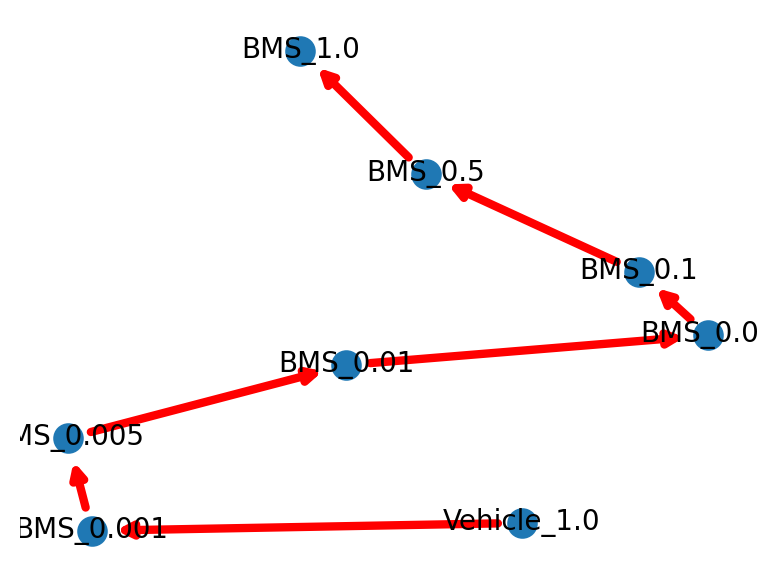

In [8]:
plt.figure(figsize=(4,3))
pos = nx.spring_layout(input_trajectories)  # positions for all nodes
nx.draw_networkx_nodes(input_trajectories, pos, node_size=100)
for u, v, data in input_trajectories.edges(data=True):
    nx.draw_networkx_edges(input_trajectories, pos, edgelist=[(u, v)], width=3, edge_color='red')
nx.draw_networkx_labels(input_trajectories, pos, font_size=10)
plt.axis("off")
plt.tight_layout()
plt.show()

# PCA Embedding

In [9]:
adata = ad.AnnData(X=adata_bms.obsm["tardis"].copy(), obs=adata_bms.obs.copy())
embedding_object = PCAEmbedding(
    random_state=42,
    pca_params={"n_comps": 10},
    adata=adata, 
    labels=adata.obs["drug_dose_name"]
)
embedding_object.calculate()

embedding_object.get_result("pca").shape

INFO:AnndataPreperation:No precomputed neighbors found in AnnData.
INFO:PCAEmbedding:Starting PCAEmbedding embedding calculation.
INFO:PCAEmbedding:Performing embedding calculation.


computing PCA
    with n_comps=10
    finished (0:00:00)


INFO:PCAEmbedding:Embedding calculation completed successfully.


(4094, 10)

In [15]:
inferred_trajectories = embedding_object.get_result("pca")
inferred_trajectories_labels = np.array(adata_bms.obs["drug_dose_name"])

In [17]:
embedding_evaluation = EmbeddingTrajectoryEvaluation(
    method_params = dict(
        metrics = [
            "curvature_deviation",
            "distance_correlation",
            "stress",
            "geodesic_distance_correlation",
        ]
    )
)

In [25]:
logging.getLogger().setLevel(logging.DEBUG)
try:
    embedding_evaluation.evaluate(
        given_trajectory=input_trajectories,
        inferred_trajectory=inferred_trajectories,
        labels=inferred_trajectories_labels
    )
finally:
    logging.getLogger().setLevel(logging.INFO)

INFO:EmbeddingTrajectoryEvaluation:Starting evaluation with EmbeddingTrajectoryEvaluation.
DEBUG:EmbeddingTrajectoryEvaluation:Verifying given trajectory.
DEBUG:EmbeddingTrajectoryEvaluation:Verifying inferred trajectory.
DEBUG:EmbeddingTrajectoryEvaluation:Verifying labels.
DEBUG:EmbeddingTrajectoryEvaluation:Checking the consistency between the given graph and labels.
DEBUG:EmbeddingTrajectoryEvaluation:Performing evaluation calculation.
DEBUG:EmbeddingTrajectoryEvaluation:Calculating metric: 'curvature_deviation'
DEBUG:EmbeddingTrajectoryEvaluation:Label 'Vehicle_1.0': centroid = [-4.867477   -0.8532664   0.19227362 -0.01551723  0.0178434  -0.05305546
  0.08588994 -0.0133437   0.04200486 -0.00897153]
DEBUG:EmbeddingTrajectoryEvaluation:Label 'BMS_0.001': centroid = [ 0.7964513   2.2749386  -1.4883505  -0.08212481 -0.2589847   0.53023213
 -0.5163004   0.03443472  0.22766839 -0.07379384]
DEBUG:EmbeddingTrajectoryEvaluation:Label 'BMS_0.005': centroid = [ 3.999246    2.3825266  -0.2265

In [26]:
embedding_evaluation.get_result()

{'curvature_deviation': 0.14797818722625894,
 'distance_correlation': 0.9748088976994393,
 'stress': 0.21113038120904912,
 'geodesic_distance_correlation': 0.968675703245105,
 'curvature_mean': 0.8537845700612327}